# Average Multiple Days Together

## Imports and Versions

In [115]:
from pygsdata import GSData
from pathlib import Path
from importlib.metadata import version

from edges_cal import modelling as mdl

from edges_analysis.averaging.combiners import average_over_times
from edges_analysis.datamodel import add_model
from edges_analysis.filters.filters import rfi_model_filter
from edges_cal.alanmode import read_spec_txt
from pygsdata import plots
import matplotlib.pyplot as plt
import numpy as np

In [136]:
plt.style.use("dark_background")

In [15]:
print("Versions: ")
for pkg in ['read_acq', 'pygsdata', 'edges-cal', 'edges-io', 'edges-analysis']:
    print(f"{pkg:>20}: {version(pkg)}")


Versions: 
            read_acq: 1.0.3.dev17+gd442d34
            pygsdata: 0.2.1.dev41+g6af6948
           edges-cal: 6.2.6.dev199+g1cd9c07
            edges-io: 4.1.8.dev4+gdcc2fad
      edges-analysis: 6.0.3.dev72+g54f5323


## Parameters and Data Loading

In [16]:
datadir: str = "/data4/smurray/edges/projects_with_nive/edges-bowman2018-pipeline/output-notebooks/"
fileglob: str = "*.finalspec.gsh5"

In [75]:
allfiles = sorted(Path(datadir).glob(fileglob))

In [73]:
allfiles[0].stem

'2016-250.finalspec'

In [74]:
for fl in allfiles:
    year = int(fl.name.split("-")[0])
    day = int(fl.name.split("-")[1].split(".")[0])
    newname = f"{year}-{day:>03}.finalspec.gsh5"
    fl.rename(fl.parent / newname)

In [71]:
allfiles[103]

PosixPath('/data4/smurray/edges/projects_with_nive/edges-bowman2018-pipeline/output-notebooks/2017-1.finalspec.gsh5')

In [18]:
print(f"Averaging together {len(allfiles)} days of data")

Averaging together 138 days of data


In [76]:
data = GSData.from_file(allfiles, concat_axis='time')

## Analysis and Averaging

### Model the spectra so we can average residuals only

When we perform the average over nights, we average the models and residuals separately (and the residuals receive frequency-dependent weights while the models do not). First, we model each night here.

In [77]:
data = add_model(data, model=mdl.models.PhysicalIono(spectral_index=-2.55, f_center=75.0, n_terms=5), nsamples_strategy='flagged-nsamples-uniform')

In [78]:
alanmodel = np.genfromtxt("/home/smurray/data4/edges/alans-pipeline/scripts/nightly_model_file.txt")

In [63]:
alan_dates = np.genfromtxt("/home/smurray/data4/edges/alans-pipeline/scripts/nightly_dates.txt")

In [45]:
alan_data = np.genfromtxt("/home/smurray/data4/edges/alans-pipeline/scripts/nightly_data.txt")

Text(0.5, 1.0, 'Difference in night-to-night models between edges-analysis and C-code')

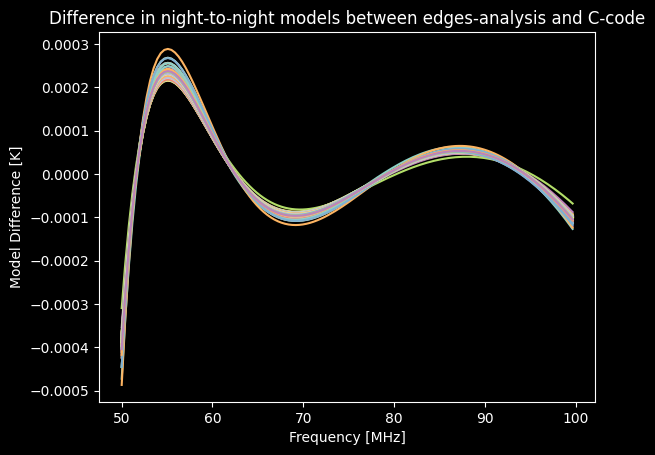

In [137]:
for i in range(data.ntimes):
    plt.plot(data.freqs, data.model[0,0,i] - alanmodel[i])
plt.xlabel("Frequency [MHz]")
plt.ylabel("Model Difference [K]")
plt.title("Difference in night-to-night models between edges-analysis and C-code")

### Some Filters

Our first filter is an RMS filter (just thresholding a whole night based on its RMS to the fitted model)

In [86]:
alanfilt = np.genfromtxt("/home/smurray/data4/edges/alans-pipeline/scripts/nightly_flagfile.txt")

In [97]:
from pygsdata.register import gsregister
from edges_analysis.filters.filters import gsdata_filter
from typing import Literal
from astropy import units as u
from edges_analysis.averaging import averaging

@gsregister("filter")
@gsdata_filter()
def rms_filter(
    data: GSData,
    threshold: float,
    freq_range: float = (0.0, np.inf),
    nsamples_strategy: Literal[
        "flagged-nsamples",
        "flags-only",
        "flagged-nsamples-uniform",
        "nsamples-only",
    ] = "flagged-nsamples",
    model: mdl.Model | None = None,
) -> bool:
    """Filter integrations based on the rms of the residuals.
    
    Parameters
    ----------
    data : GSData
        The data to be filtered.
    threshold
        The threshold at which to flag integrations.
    freq_range : float, optional
        The frequency range to use in calculating the RMS.
    nsamples_strategy : str, optional
        The strategy to use when defining the weights of each sample. Defaults to
        'flagged-nsamples'. The choices are:
        - 'flagged-nsamples': Use the flagged nsamples (i.e. set nsamples at flagged
            data to zero, otherwise use nsamples)
        - 'flags-only': Use the flags only (i.e. set nsamples at flagged data to
            zero, otherwise use 1)
        - 'flagged-nsamples-uniform': Use the flagged nsamples (i.e. set nsamples at
            flagged data to zero, and keep zero-samples as zero, otherwise use 1)
        - 'nsamples-only': Use the nsamples only (don't set nsamples at flagged
            data to zero)
    model : Model, optional
        A model to be used to fit each integration. Not required if a model
        already exists on the data.
    """
    if freq_range[0]*u.MHz > data.freqs.min() or freq_range[1]*u.MHz < data.freqs.max():
        data = flag_frequency_ranges(data=data, freq_ranges=[freq_range], invert=True)

    if data.residuals is None:
        if model is None:
            raise ValueError(
                "Cannot perform object rms filter without residuals or a model."
            )
        data = add_model(data=data, model=model, nsamples_strategy=nsamples_strategy)
        
    shp = (-1, data.nfreqs)
    if nsamples_strategy == "flagged-nsamples":
        w = data.flagged_nsamples.reshape(shp)
    elif nsamples_strategy == "flags-only":
        w = (~data.complete_flags.reshape(shp)).astype(float)
    elif nsamples_strategy == "flagged-nsamples-uniform":
        w = (data.flagged_nsamples > 0).astype(float).reshape(shp)
    elif nsamples_strategy == "nsamples-only":
        w = np.nsamples.reshape(shp)
    
    rms = np.sqrt(
        averaging.weighted_mean(data=data.residuals.reshape(shp)**2, weights=w, axis=-1)[0]
    )

    return GSFlag(
        flags=(rms > threshold).reshape(data.data.shape[:-1]),
        axes=("load", "pol", "time",),
    )


In [98]:
rms_data = rms_filter(data, threshold=0.17, nsamples_strategy='flagged-nsamples-uniform') 

In [107]:
assert np.sum(~rms_data.flags['rms_filter'].flags[0,0] ^ alanfilt[:, 1].astype(bool))==0

In [109]:
rms_data = filters.prune_flagged_integrations(rms_data)

In [110]:
print(rms_data.ntimes)

81


Based on the model already fit, we perform simple RFI-flagging, where we flag any channel whose residual is larger than a threshold multiplied by the RMS of the residuals that night (over frequency).

In [81]:
from edges_analysis.filters import filters
from pygsdata import GSFlag

In [82]:
@filters.gsdata_filter()
def rms_rfi_filter(data: GSData, threshold):
    ns = (data.nsamples[0,0] > 0).astype(float)
    
    rms = np.sqrt(np.average(np.square(data.residuals[0,0]), weights=ns, axis=1))[None, None, :, None]
    return GSFlag(flags=data.residuals > rms * threshold, axes=("load", "pol", "time", "freq"))

In [112]:
filt_data = rms_rfi_filter(rms_data, threshold=1.9)

Now, make sure that we flagged exactly the same channels/nights as the C-code

In [114]:
alanweights= np.genfromtxt("/home/smurray/data4/edges/alans-pipeline/scripts/nightly_weights.txt")
weights= filt_data.flagged_nsamples[0,0] > 0
assert np.sum(weights ^ alanweights.astype(bool))==0

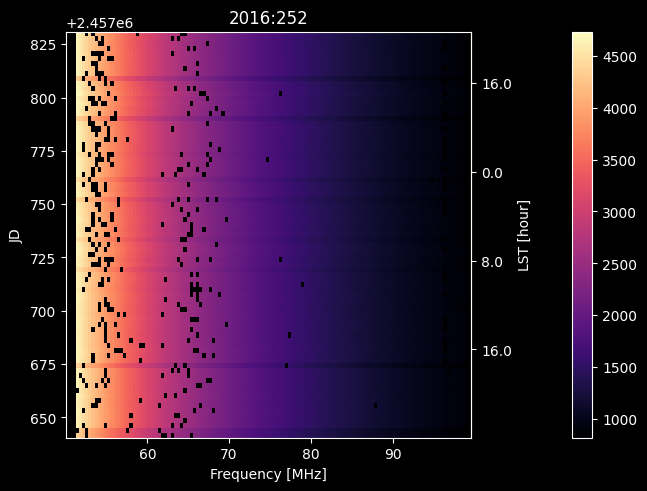

In [138]:
plots.plot_waterfall(filt_data);

### Average all nights

In [119]:
avg_data = average_over_times(filt_data, use_resids=True, nsamples_strategy='flagged-nsamples-uniform')

/data4/smurray/edges/edges-analysis/src/edges_analysis/averaging/combiners.py:89: RuntimeWarning: invalid value encountered in divide
  mean_resids = sum_resids / ntot


### Last RFI Filter

In [120]:
avg_data = add_model(avg_data, model=mdl.Polynomial(offset=-2.5, n_terms=7, transform=mdl.ScaleTransform(scale=75.0)), nsamples_strategy='flagged-nsamples-uniform')

In [121]:
final_data = rms_rfi_filter(avg_data, threshold=1.9)

In [122]:
final_data = add_model(final_data, model=mdl.LinLog(n_terms=5))

## Inspect Final Results

In [123]:
alan_fl = "/home/smurray/data4/edges/alans-pipeline/scripts/H2CaseFieldData/final_average_2024-10-02_01-18.txt"
alan = np.genfromtxt(alan_fl, usecols=(1, 3, 6, 9, 12), names=('freq', 'tant', 'model', 'resid', 'weight'))

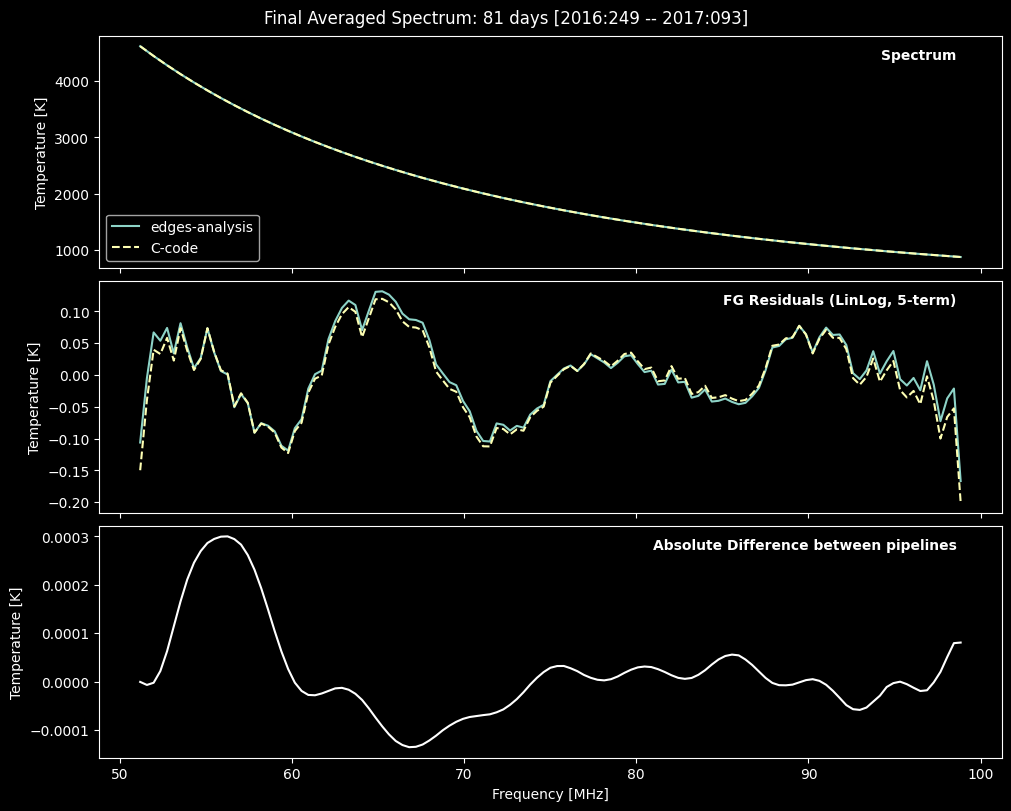

In [140]:
fig, ax = plt.subplots(3, 1, sharex=True, figsize=(10, 8), constrained_layout=True)

ax[0].plot(final_data.freqs, np.where(final_data.flagged_nsamples[0,0,0]>0, final_data.data[0,0,0], np.nan), label='edges-analysis')
ax[0].plot(final_data.freqs, np.where(alan['weight']>0, alan['tant'], np.nan), label='C-code', ls='--')
ax[0].legend()
ax[0].text(0.95, 0.9, "Spectrum", transform=ax[0].transAxes, ha='right', fontweight='bold')

for i in range(3):
    ax[i].set_ylabel("Temperature [K]")
    
ttmin = data.times.min().datetime.timetuple()
ttmax = data.times.max().datetime.timetuple()

fig.suptitle(f"Final Averaged Spectrum: {rms_data.ntimes} days [{ttmin.tm_year}:{ttmin.tm_yday:>03} -- {ttmax.tm_year}:{ttmax.tm_yday:>03}]")

ax[1].plot(final_data.freqs, np.where(final_data.flagged_nsamples[0,0,0]>0, final_data.residuals[0,0,0], np.nan))
alresid = mdl.LinLog(n_terms=5).fit(xdata=final_data.freqs, ydata=alan['tant'], weights=data.nsamples[0,0,0])

ax[1].plot(final_data.freqs, np.where(final_data.flagged_nsamples[0,0,0]>0, alresid.residual, np.nan), ls='--')
ax[1].text(0.95, 0.9, "FG Residuals (LinLog, 5-term)", transform=ax[1].transAxes, ha='right', fontweight='bold')


ax[2].plot(final_data.freqs, np.where(final_data.flagged_nsamples[0,0,0]>0, final_data.data[0,0,0] - alan['tant'], np.nan), color='w')
ax[2].set_xlabel("Frequency [MHz]")
ax[2].text(0.95, 0.9, "Absolute Difference between pipelines", transform=ax[2].transAxes, ha='right', fontweight='bold');


We ensure that we have all the same flags as the C-code:

In [126]:
assert np.sum((final_data.flagged_nsamples > 0) ^ alan['weight'].astype(bool))==0

## Write out the data

In [127]:
final_data.write_gsh5(Path(datadir) / "averaged_spectrum.gsh5");